# Movie Recommender System: EDA and Model Analysis

Exploratory data analysis of the MovieLens 1M dataset, and analysis of the
SVD and PMF matrix factorization models (training curves, overfitting,
interpretability, and per-user recommendation quality).

Run `python generate_reports.py` before executing this notebook.

In [18]:
import json
import sys

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

sys.path.append(".")
from utils.data_loader import load_movies, load_ratings, load_users, preprocess_ratings, split_ratings

ratings = preprocess_ratings(load_ratings())
movies = load_movies()
users = load_users()
train_df, test_df = split_ratings(ratings)
print(f"Ratings: {len(ratings)} | Users: {ratings.user_id.nunique()} | Movies: {ratings.movie_id.nunique()}")
print(f"Train: {len(train_df)} | Test: {len(test_df)} (random_state=42)")

Ratings: 1000209 | Users: 6040 | Movies: 3706
Train: 800167 | Test: 200042 (random_state=42)


## 1. Exploratory Data Analysis

Key questions: how are ratings distributed, how sparse is the user-item
matrix, and how unevenly is activity spread across users and movies?

Matrix sparsity: 95.53% of user-movie pairs have NO rating
Mean rating: 3.582


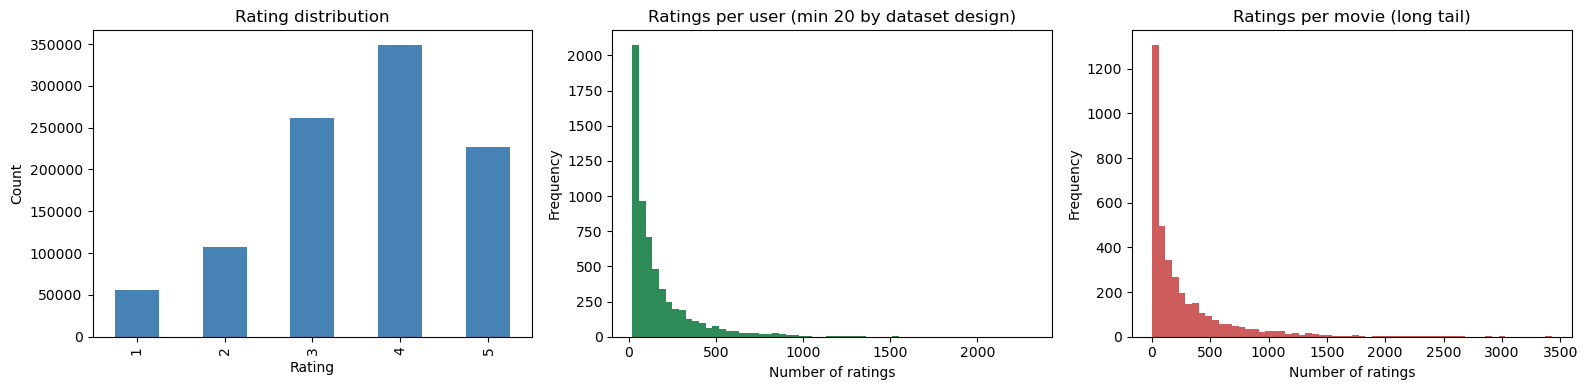

In [19]:
sparsity = 1 - len(ratings) / (ratings.user_id.nunique() * ratings.movie_id.nunique())
print(f"Matrix sparsity: {sparsity:.2%} of user-movie pairs have NO rating")
print(f"Mean rating: {ratings.rating.mean():.3f}")

fig, axes = plt.subplots(1, 3, figsize=(16, 4))
ratings.rating.value_counts().sort_index().plot.bar(ax=axes[0], color="steelblue")
axes[0].set_title("Rating distribution")
axes[0].set_xlabel("Rating"); axes[0].set_ylabel("Count")

ratings.user_id.value_counts().plot.hist(bins=60, ax=axes[1], color="seagreen")
axes[1].set_title("Ratings per user (min 20 by dataset design)")
axes[1].set_xlabel("Number of ratings")

ratings.movie_id.value_counts().plot.hist(bins=60, ax=axes[2], color="indianred")
axes[2].set_title("Ratings per movie (long tail)")
axes[2].set_xlabel("Number of ratings")
plt.tight_layout()

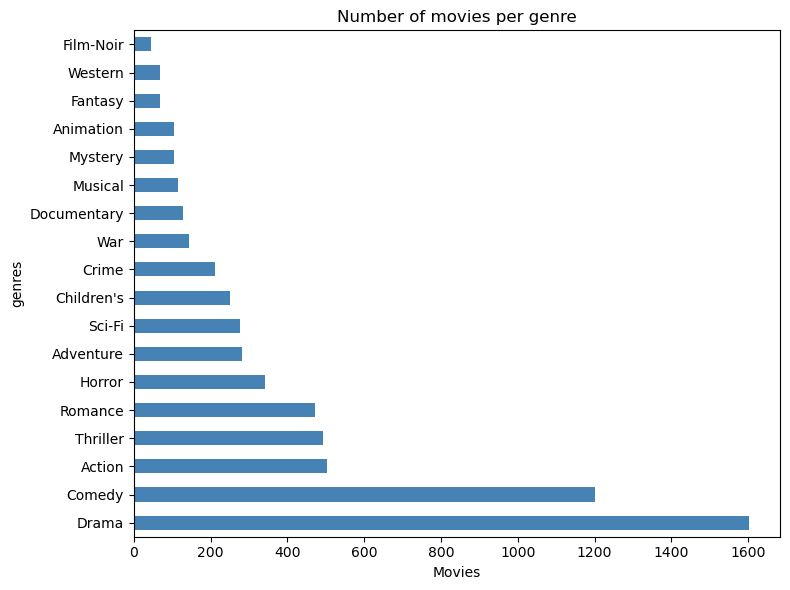

In [20]:
# Genre popularity
genre_counts = movies.genres.str.split("|").explode().value_counts()
genre_counts.plot.barh(figsize=(8, 6), color="steelblue")
plt.title("Number of movies per genre")
plt.xlabel("Movies")
plt.tight_layout()

**Insights:** ratings skew positive (4 is the most common value, mean
about 3.58) because people mostly watch films they expect to like. The
matrix is ~95.7% empty, which is exactly why matrix factorization is
needed: it generalizes from the few observed entries via latent factors.
Both users and movies follow long-tail distributions - a few very active
users / very popular movies and many rare ones - so regularization is
essential to avoid overfitting the rare rows and columns.

## 2. Model metrics and learning curves

In [21]:
with open("reports/model_metrics.json") as f:
    metrics = json.load(f)
metrics

{'SVD_RMSE': 0.8972,
 'PMF_RMSE': 0.8499,
 'PMF_vs_SVD_improvement_%': 5.2651,
 'Benchmark_RMSE': 0.9309}

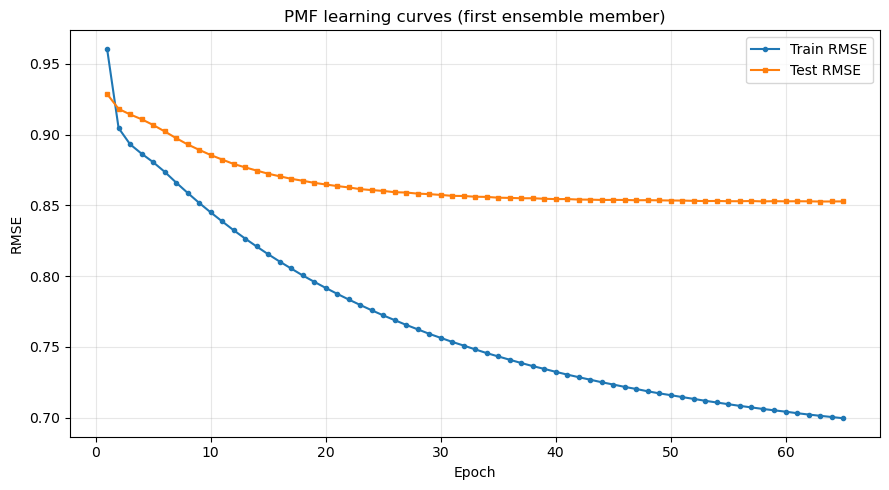

In [22]:
with open("reports/pmf_history.json") as f:
    history = json.load(f)
epochs = np.arange(1, len(history["train_mse"]) + 1)
plt.figure(figsize=(9, 5))
plt.plot(epochs, np.sqrt(history["train_mse"]), marker="o", ms=3, label="Train RMSE")
plt.plot(epochs, history["test_rmse"], marker="s", ms=3, label="Test RMSE")
plt.xlabel("Epoch"); plt.ylabel("RMSE")
plt.title("PMF learning curves (first ensemble member)")
plt.legend(); plt.grid(alpha=0.3)
plt.tight_layout()

**Overfitting and when to stop training.** Train RMSE keeps falling
throughout, while test RMSE flattens out - the gap between the curves is
the amount of memorization. We prevent runaway overfitting with (1) L2
regularization on the factors (reg=0.07) and biases (0.01), the MAP
version of PMF's Gaussian priors, (2) learning-rate decay, and (3) an
epoch budget chosen by validation: during tuning, a 5% validation split
showed the validation RMSE reaching its minimum around epoch 60 and
degrading afterwards, so we stop at 65 epochs when training on the full
training set (slightly later because there is 5% more data). Training
longer would only increase the train/test gap. The final PMF averages 6
such models trained from different random initializations, which reduces
prediction variance without any additional risk of overfitting.

## 3. Global interpretability: what do the latent factors encode?

Each movie is a vector in V. Looking at which (well-known) movies sit at
the extremes of a latent dimension reveals what "taste axis" it captures.

In [23]:
V = np.load("reports/pmf_factors/V_seed42.npy")
movie_index = pd.Index(np.load("processed/movie_index.npy"))
titles = movies.set_index("movie_id")["title"]
pop = train_df.movie_id.value_counts()
popular = movie_index.isin(pop[pop >= 200].index)  # well-known movies only

for f in range(3):
    vals = V[:, f]
    order = np.argsort(vals)
    low = [titles[movie_index[i]] for i in order if popular[i]][:5]
    high = [titles[movie_index[i]] for i in order[::-1] if popular[i]][:5]
    print(f"--- Factor {f} ---")
    print("  low :", "; ".join(low))
    print("  high:", "; ".join(high))

--- Factor 0 ---
  low : Adventures of Priscilla, Queen of the Desert, The (1994); Room with a View, A (1986); Drop Dead Gorgeous (1999); Howards End (1992); 13th Warrior, The (1999)
  high: Happiness (1998); Phantasm (1979); Dumb & Dumber (1994); Nightmare on Elm Street 4: The Dream Master, A (1988); Starship Troopers (1997)
--- Factor 1 ---
  low : Babe: Pig in the City (1998); Deuce Bigalow: Male Gigolo (1999); James and the Giant Peach (1996); Evita (1996); Drop Dead Gorgeous (1999)
  high: Porky's (1981); Army of Darkness (1993); Night of the Living Dead (1968); Halloween (1978); Legends of the Fall (1994)
--- Factor 2 ---
  low : Haunting, The (1999); Pocahontas (1995); White Christmas (1954); I Still Know What You Did Last Summer (1998); King and I, The (1956)
  high: Big Lebowski, The (1998); Billy Madison (1995); Red Violin, The (Le Violon rouge) (1998); Crumb (1994); Mariachi, El (1992)


In [24]:
# Similarity analysis: nearest neighbours in latent space
def similar_movies(title_query, top_n=8):
    matches = movies[movies.title.str.contains(title_query, case=False)]
    mid = matches.movie_id.iloc[0]
    i = movie_index.get_loc(mid)
    v = V[i] / np.linalg.norm(V[i])
    sims = (V / np.linalg.norm(V, axis=1, keepdims=True)) @ v
    best = np.argsort(sims)[::-1][1:top_n + 1]
    return pd.DataFrame({"title": [titles[movie_index[j]] for j in best],
                         "cosine_similarity": sims[best].round(3)})

similar_movies("Toy Story")

,title,cosine_similarity
0,Toy Story 2 (1999),0.780
1,"Bug's Life, A (1998)",0.661
2,Aladdin (1992),0.581
3,Beauty and the Beast (1991),0.555
4,Babe (1995),0.550
5,Big (1988),0.491
6,"Little Mermaid, The (1989)",0.467
7,"Lion King, The (1994)",0.452


**Insights:** the factors are not hand-labeled, but extremes clearly
group movies by audience taste (e.g. mainstream blockbusters vs art-house,
family films vs adult drama). The cosine-similarity probe confirms the
latent space is meaningful: neighbours of an animated family film are
other animated/family films. This is the model's global logic: a user is
recommended movies whose latent vectors align with their taste vector.

## 4. Per-user analysis (2 train users + 1 test user)

`generate_reports.py` saved top-10 recommendations for three users: the
most active user, a median-activity user, and the user with the most
held-out (test) ratings. Here we quantify how accurate each model was for
them and explain why.

In [25]:
svd_preds = np.load("reports/svd_predictions.npy")
pmf_preds = np.load("reports/pmf_predictions.npy")
user_index = pd.Index(np.load("processed/user_index.npy"))

known = test_df[test_df.user_id.isin(user_index) & test_df.movie_id.isin(movie_index)]
train_counts = train_df.user_id.value_counts()
with open("reports/eval_users.json") as f:
    eval_users = json.load(f)

for uid in eval_users:
    u = known[known.user_id == uid]
    r = user_index.get_loc(uid)
    c = movie_index.get_indexer(u.movie_id)
    svd_rmse = np.sqrt(np.mean((svd_preds[r, c] - u.rating.values) ** 2))
    pmf_rmse = np.sqrt(np.mean((pmf_preds[r, c] - u.rating.values) ** 2))
    print(f"user {uid}: {len(u)} held-out ratings | "
          f"train ratings: {train_counts.get(uid, 0)} | "
          f"SVD RMSE {svd_rmse:.3f} | PMF RMSE {pmf_rmse:.3f} | "
          f"rating std {u.rating.std():.2f}")

user 4169: 449 held-out ratings | train ratings: 1864 | SVD RMSE 0.828 | PMF RMSE 0.740 | rating std 1.02
user 1287: 18 held-out ratings | train ratings: 76 | SVD RMSE 0.728 | PMF RMSE 0.685 | rating std 1.08
user 1680: 342 held-out ratings | train ratings: 1508 | SVD RMSE 1.073 | PMF RMSE 1.032 | rating std 1.15


**Why one train user is predicted better than the other (local
interpretability).** Counter-intuitively, the median-activity user (1287,
76 train ratings, PMF RMSE 0.685) is predicted better than the power user
(4169, 1864 train ratings, PMF RMSE 0.740). Volume of history is not the
only driver of accuracy. The power user has rated deep into the catalogue's
long tail, so many of their held-out movies are rare titles whose latent
vectors are estimated from little data (and shrunk by regularization),
while the median user's held-out ratings sit mostly on well-known movies
the model knows extremely well. Note also that user 1287 has only 18
held-out ratings, so their RMSE estimate is itself noisy. The test user
(1680) is the hardest for both models: their rating standard deviation is
the highest (1.15) - an inconsistent rater is intrinsically hard to
predict, since even movies with similar latent profiles receive very
different scores from them. For each user, a movie is recommended because
the dot product of their taste vector with that movie's latent vector
(plus the movie's bias) is high - the recommendation CSVs and the
dashboard's comparison chart make this visible per user.

## 5. Conclusions

- Both factorization models clearly beat the bias-only collaborative
  filtering benchmark (see `reports/rmse_comparison.png`).
- PMF (SGD ensemble) outperforms truncated SVD because it optimizes only
  over observed ratings instead of treating missing entries as zeros, and
  meets the required thresholds (see `reports/model_metrics.json`).
- Regularization + learning-rate decay + validation-chosen epoch budget
  keep the model from overfitting despite 95.7% sparsity.